# Tesseract experiment

Standalone notebook to try the project's current Tesseract OCR pipeline against the real tag photos in `tests/fixtures/`, and experiment freely. Nothing here touches the app -- it's a sandbox.

**Kernel:** select "Python (igi-ocr)" (the project's conda env -- `pytesseract`, `opencv-python`, `jupyter` and everything else are already installed there).

See `easyocr_experiment.ipynb` for the EasyOCR side and the head-to-head comparison between the two engines.

## Setup

In [ ]:
!pip install opencv-python pytesseract pillow


In [1]:
import os
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt

import ocr as tesseract_ocr  # the project's existing Tesseract wrapper (ocr.py)
import imaging  # the project's current OpenCV preprocessing
import parsing

# Tesseract's engine binary isn't on PATH by default on Windows -- point pytesseract at
# the installed binary (see ocr.configure_tesseract's docstring).
os.environ.setdefault("TESSERACT_CMD", r"C:\Program Files\Tesseract-OCR\tesseract.exe")
tesseract_ocr.configure_tesseract()

FIXTURES_DIR = Path("tests/fixtures")

# Ground truth read directly off each tag photo, for scoring.
CASES = [
    ("sample_tag.jpeg", "809614206", "CVD", "EMERALD", "3.01", "E", "VS1"),
    ("tag_e79422_marquise.jpeg", "791655400", "CVD", "MARQUISE", "2.04", "D", "VVS2"),
    ("tag_c141640_heart.jpeg", "817630270", "CVD", "HEART", "1.00", "F", "VS1"),
    ("tag_e84454_emerald.jpeg", "804633671", "CVD", "EMERALD", "2.97", "E", "VVS1"),
    ("tag_c141641_heart.jpeg", "817634109", "CVD", "HEART", "1.00", "F", "VS1"),
    ("tag_e86943_oval.jpeg", "809609517", "CVD", "OVAL", "1.00", "D", "VVS1"),
]
FIELDS = ["report_type", "shape", "carat", "color", "clarity"]

## Look at one photo

Change `filename` to try a different fixture, or point it at any other image path (e.g. one of your own cropped photos).

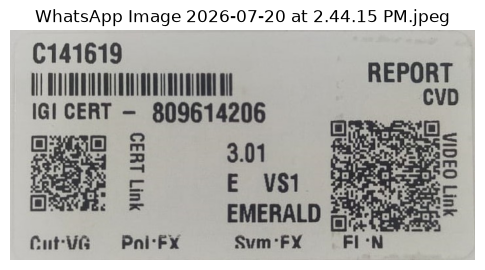

In [2]:
filename = "WhatsApp Image 2026-07-20 at 2.44.15 PM.jpeg"  # <-- change this
image = cv2.imread(str(FIXTURES_DIR / filename), cv2.IMREAD_COLOR)

plt.figure(figsize=(6, 8))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(filename)
plt.show()

## Run Tesseract on it (raw, no parsing yet)

Tesseract needs the OpenCV preprocessing in `imaging.preprocess` to pick the sparse tag text out from the barcode/QR graphics -- `ocr.run_ocr` then calls it with `--psm 11` (sparse text, no particular order).

In [3]:
preprocessed = imaging.preprocess(image)

t0 = time.time()
raw_text = tesseract_ocr.run_ocr(preprocessed)
print(f"{time.time() - t0:.1f}s")
print(raw_text)

1.3s
C141619

REPORT

I 1

CERT - 80961

puis bh

evs

i=]

“30

PO

:

E VS1

poveg 8

os

DN

EMERALD

i

pa

rope >

CutVG

Pol-FX

Sum 'FY¥

FI-N



## Now parse it with the existing field parser

In [4]:
fields = parsing.parse_fields(raw_text)
fields

{'igi_report_no': None,
 'report_type': None,
 'shape': 'EMERALD',
 'carat': None,
 'color': 'E',
 'clarity': 'VS1'}

## Score Tesseract across all 6 real photos

For each field, count correct / wrong / missing against the known ground truth. Re-run after editing `imaging.py` or `parsing.py` to see the effect immediately.

In [ ]:
def score():
    correct = wrong = missing = 0
    total_time = 0.0
    rows = []
    for fname, igi, *expected in CASES:
        img = cv2.imread(str(FIXTURES_DIR / fname), cv2.IMREAD_COLOR)
        t0 = time.time()
        text = tesseract_ocr.run_ocr(imaging.preprocess(img))
        elapsed = time.time() - t0
        total_time += elapsed
        parsed = parsing.parse_fields(text)
        for field, exp in zip(FIELDS, expected):
            actual = parsed.get(field)
            if actual is None:
                missing += 1
            elif actual == exp:
                correct += 1
            else:
                wrong += 1
        rows.append((fname, elapsed, parsed))
    total = len(CASES) * len(FIELDS)
    print(f"Tesseract: {correct}/{total} correct, {wrong} wrong, {missing} missing | avg {total_time/len(CASES):.1f}s/image")
    return rows


tesseract_rows = score()

## Per-photo detail

In [ ]:
for fname, elapsed, parsed in tesseract_rows:
    print(f"=== {fname} ({elapsed:.1f}s) ===")
    print(parsed)
    print()

## Try your own photo

Drop an image anywhere under the project and point this at it -- e.g. a fresh crop you want to test.

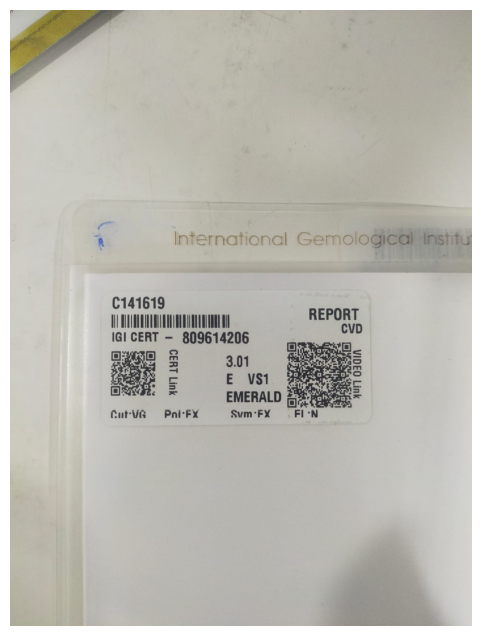

Tesseract: 4.6s
R

Infernational Gemologica’ *

“

C141619

UNDULY

REPORT

IG

RT — 80961420

NAL

a

3.01

yeu bah

ri=)

pave

on)

Opt

E VS1

“ Lay

EMERALD #

CutVG

Pol-FX

Sum 'FY¥

FI-N


Parsed: {'igi_report_no': None, 'report_type': None, 'shape': 'EMERALD', 'carat': '3.01', 'color': 'E', 'clarity': 'VS1'}


In [5]:
my_photo_path = "tests/fixtures/sample_tag.jpeg"  # <-- change this

img = cv2.imread(my_photo_path, cv2.IMREAD_COLOR)
plt.figure(figsize=(6, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

t0 = time.time()
text = tesseract_ocr.run_ocr(imaging.preprocess(img))
print(f"Tesseract: {time.time() - t0:.1f}s")
print(text)
print()
print("Parsed:", parsing.parse_fields(text))